# Superstore — Xử lý dữ liệu cho Dashboard YTD/YoY

1. **Inspection phase** — xác nhận dữ liệu phù hợp cho quá trình giả lập dashboard YTD/YoY chương 10 (columns phù hợp, đúng kiểu dữ liệu, cả hai năm so sánh sử dụng trong dashboard đều có dữ liệu ổn định)
2. **Pipeline phase** — clean, giữ lại đúng những columns dashboard cần, thêm các date helper mà Tableau dùng được, và ghi file CSV đã rút gọn ra thư mục đích

Output là `data/processed/superstore_dashboard.csv`, sẵn sàng sử dụng cho workbook

---
## Phase 1 · Inspection (Kiểm tra dữ liệu)

### 1.1 · Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

RAW_PATH = Path("/workspace/data/raw/superstore.csv") # input path
OUT_DIR  = Path("/workspace/data/processed") # destination folder
OUT_PATH = OUT_DIR / "superstore_dashboard.csv"

# Dashboard cần 3 thứ: một cột ngày, một measure, và một location dimension.
# Ngày & measure là hiển nhiên; location dimension sẽ được CHỌN ở mục 1.3.
DATE_COL = "Order Date"
MEASURE  = "Sales"

# Các cột địa lý ứng viên cho location dimension — đánh giá ở 1.3
GEO_CANDIDATES = ["City", "State", "Country", "Postal Code", "Market", "Region"]

# DASHBOARD_COLS được chốt ở 1.3 sau khi chọn xong location dimension.

# Khoảng thời gian so sánh
CURRENT_YEAR = 2014
PREV_YEAR    = CURRENT_YEAR - 1
AS_OF_MONTH  = 6

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

### 1.2 · Load data

In [2]:
raw = pd.read_csv(RAW_PATH, encoding="cp1252")
print(f"Loaded {raw.shape[0]:,} rows × {raw.shape[1]} columns")
print()
print("Columns:")
for c in raw.columns:
    flag = "  ← ứng viên location dimension" if c in GEO_CANDIDATES else ""
    print(f"  • {c}{flag}")

Loaded 51,290 rows × 24 columns

Columns:
  • Row ID
  • Order ID
  • Order Date
  • Ship Date
  • Ship Mode
  • Customer ID
  • Customer Name
  • Segment
  • City  ← ứng viên location dimension
  • State  ← ứng viên location dimension
  • Country  ← ứng viên location dimension
  • Postal Code  ← ứng viên location dimension
  • Market  ← ứng viên location dimension
  • Region  ← ứng viên location dimension
  • Product ID
  • Category
  • Sub-Category
  • Product Name
  • Sales
  • Quantity
  • Discount
  • Profit
  • Shipping Cost
  • Order Priority


### 1.3 · Chọn column nào làm *location dimension*?

Dashboard YTD/YoY xếp hạng sales theo địa điểm — nhưng dữ liệu có tới **sáu** cột địa lý (`City`, `State`, `Country`, `Postal Code`, `Market`, `Region`). Chọn cột nào không phải cảm tính: một location dimension tốt cho dashboard *này* cần sáu thuộc tính, mỗi thuộc tính kiểm được bằng con số.

1. **Cardinality đúng** — đủ ít giá trị để xếp hạng trực quan được (sách dùng 6; tối đa ~15 vẫn vừa màn mobile). Quá nhiều bar thì chart không đọc được.
2. **Label nhất quán** — mỗi địa điểm có đúng một cách viết (không `"east"` lẫn `"East "`).
3. **Ổn định theo thời gian** — cùng tập giá trị ở cả hai năm so sánh; nếu một giá trị chỉ có ở một năm thì nửa YoY bị lệch.
4. **Phân bố cân bằng** — không giá trị nào quá lớn làm phần còn lại bị méo (target < 40% tổng sales).
5. **Coverage đầy đủ** — mọi row đều có giá trị (không null).
6. **Hierarchy hợp lý** — nest gọn dưới một level cao hơn và chứa một level thấp hơn (drill-down sau này).

Scorecard dưới đây chấm cả sáu ứng viên theo năm tiêu chí định lượng đầu; tiêu chí 6 (hierarchy) xét riêng ở phần kết luận.

In [3]:
# Year/month helper cục bộ cho tiêu chí "ổn định theo thời gian"
_dt     = pd.to_datetime(raw[DATE_COL], format="%d-%m-%Y", errors="coerce")
_year   = _dt.dt.year
_in_ytd = _dt.dt.month <= AS_OF_MONTH

def score_location(col):
    s = raw[col]
    # (2) consistency: gộp theo dạng chuẩn hoá (strip+lower) — có nhiều cách viết không?
    nonnull  = s.dropna().astype(str)
    variants = nonnull.groupby(nonnull.str.strip().str.lower()).nunique()
    # (4) distribution: share của giá trị lớn nhất
    grp_share = raw.groupby(col)[MEASURE].sum()
    # (3) stability: cùng tập giá trị ở hai năm so sánh (trong cửa sổ YTD)?
    cur  = set(raw.loc[_in_ytd & (_year == CURRENT_YEAR), col].dropna())
    prev = set(raw.loc[_in_ytd & (_year == PREV_YEAR),    col].dropna())
    return {
        "distinct":      s.nunique(dropna=True),                       # (1) cardinality
        "null %":        round(s.isna().mean() * 100, 1),             # (5) coverage
        "spelling vars": int((variants > 1).sum()),                   # (2) consistency
        "top share %":   round(grp_share.max() / grp_share.sum() * 100, 1),  # (4)
        "chỉ ở 1 năm":   len(cur ^ prev),                             # (3) stability
    }

scorecard = pd.DataFrame({c: score_location(c) for c in GEO_CANDIDATES}).T
scorecard.index.name = "column"
print("Scorecard location dimension")
print("(target: distinct 2-20 · null 0% · spelling vars 0 · top share < 40% · chỉ-ở-1-năm = 0)\n")
print(scorecard.to_string())

Scorecard location dimension
(target: distinct 2-20 · null 0% · spelling vars 0 · top share < 40% · chỉ-ở-1-năm = 0)

             distinct  null %  spelling vars  top share %  chỉ ở 1 năm
column                                                                
City           3636.0     0.0            0.0          2.0       1368.0
State          1094.0     0.0            0.0          3.8        326.0
Country         147.0     0.0            0.0         18.2         21.0
Postal Code     631.0    80.5            0.0          3.4        216.0
Market            7.0     0.0            0.0         28.4          0.0
Region           13.0     0.0            0.0         22.3          0.0


**Đọc scorecard.**

| Ứng viên | Vấn đề |
|---|---|
| `City` (3 636), `State` (1 094), `Postal Code` (631) | Cardinality quá lớn — không xếp hạng thành bar chart đọc được. `City`/`State` còn có hàng trăm–nghìn giá trị chỉ xuất hiện ở một năm (YoY lệch), và `Postal Code` thì ~80% null. |
| `Country` (147) | Sạch, không null, nhưng 147 bar vẫn vượt xa visual budget. |
| `Market` (7) | Pass mọi tiêu chí, nhưng là level *cha* — thô, và bar lớn nhất (APAC) chiếm ~28% (gần ngưỡng 40% hơn). |
| `Region` (13) | Pass mọi tiêu chí: 0 null, 0 spelling variant, 0 giá trị lệch năm, bar lớn nhất chỉ ~22%. |

Chỉ `Market` và `Region` lọt qua tiêu chí cardinality. Giữa hai cái, **`Region` là lựa chọn phù hợp nhất**: mịn hơn `Market` một bậc (13 vs 7 — vẫn trong budget ≤ 15), phân bố cân bằng hơn (22% vs 28%), và nằm đúng giữa hierarchy (`Market` → **`Region`** → `Country`) cho drill-down về sau.

In [4]:
LOCATION_COL   = "Region"
DASHBOARD_COLS = [DATE_COL, LOCATION_COL, MEASURE]
print(f"Location dimension đã chọn : {LOCATION_COL}")
print(f"Dashboard columns          : {DASHBOARD_COLS}")

# Sales theo Region — dùng lại cho phần kiểm tra phân bố & hierarchy bên dưới
share = raw.groupby(LOCATION_COL)[MEASURE].sum().sort_values(ascending=False)

Location dimension đã chọn : Region
Dashboard columns          : ['Order Date', 'Region', 'Sales']


#### Trực quan hóa phép kiểm phân bố
Câu chuyện bar chart phụ thuộc vào việc các region *so sánh được với nhau* — tức là region lớn nhất không được lấn át đến mức các region nhỏ trở thành những vạch mờ không đọc được. Một biểu đồ nhanh sẽ làm rõ điều này.

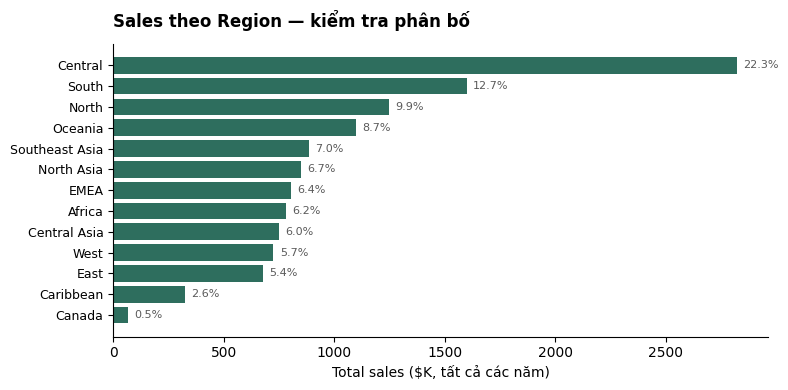

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
share_pct = (share / share.sum() * 100).round(1)
bars = ax.barh(share.index[::-1], share.values[::-1] / 1000, color='#2e6e5e')
ax.set_xlabel('Total sales ($K, tất cả các năm)')
ax.set_title('Sales theo Region — kiểm tra phân bố', loc='left', pad=12, fontweight='bold')
for bar, pct in zip(bars, share_pct.values[::-1]):
    ax.text(bar.get_width() + max(share.values) / 1000 * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=8, color='#5a5a5a')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout(); plt.show()

**Đọc biểu đồ.** Central lớn nhất với ~22% — thấy rõ nhưng không lấn át. 12 regions còn lại đều có thể so sánh được, nên bar chart đọc tốt: mỗi region đều có đủ độ dài thanh để so sánh với nhau và với reference line năm trước.

#### Hierarchy nhanh
Context hữu ích — *mỗi* Region thuộc Market nào, và phủ bao nhiêu countries. Đây là nền tảng cho drill-down dashboard sau này.

In [6]:
hierarchy = (raw.groupby(['Market', 'Region'])
                .agg(countries=('Country', 'nunique'),
                     sales=('Sales', 'sum'))
                .sort_values(['Market', 'sales'], ascending=[True, False]))
hierarchy['sales'] = hierarchy['sales'].round(0)
hierarchy

countries      sales
Market Region                              
APAC   Oceania                 3  1100185.0
       Southeast Asia          8   884423.0
       North Asia              6   848310.0
       Central Asia            6   752827.0
Africa Africa                 45   783773.0
Canada Canada                  1    66928.0
EMEA   EMEA                   40   806161.0
EU     Central                 6  1720553.0
       North                   6   625575.0
       South                   3   591961.0
LATAM  North                   1   622591.0
       South                  10   617224.0
       Central                 5   600510.0
       Caribbean               8   324281.0
US     West                    1   725458.0
       East                    1   678781.0
       Central                 1   501240.0
       South                   1   391722.0

**Kết luận.** `Region` là lựa chọn location dimension cho dashboard *này*, kèm một điểm cần biết:

- ✓ 13 giá trị — vừa visual budget mà sách khuyến nghị.
- ✓ Không có spelling variants, không null, cùng tập regions ở cả hai năm so sánh.
- ✓ Region lớn nhất chiếm 22% sales — dưới ngưỡng "lấn át" 40% khá nhiều.
- ⓘ Các tên `Central`, `South`, `North` **mỗi tên được dùng ở nhiều Markets** (Central tồn tại ở EU, LATAM, và US). Trên toàn cầu, location key thật là `(Market, Region)` — 18 tổ hợp duy nhất, không phải 13.

**Điều này có ý nghĩa gì với dashboard.** Setup hiện tại cộng cả ba "Central" thành một bar (~22% sales) — vẫn *đúng* và trả lời câu hỏi "global Central performance thế nào?" — nhưng đây là cách cắt thô hơn so với dữ liệu cho phép. Nếu sau này muốn region-level fidelity (Central-EU vs Central-LATAM vs Central-US xếp hạng riêng), chuyển location dimension thành composite `Market + " · " + Region`. Khi đó có 18 rows — vẫn trong visual budget — và loại bỏ aggregation ẩn.

### 1.4 · Audit dữ liệu

- **Order Date** — parse được dạng `DD-MM-YYYY` chưa? Có null không? Range có hợp lý không?
- **Region** — có null hoặc whitespace bất thường không? Có bao nhiêu giá trị phân biệt?
- **Sales** — numeric, không null, không âm?
- **Row ID** — duy nhất (không có row trùng để khỏi đếm gấp đôi)?

In [7]:
report = {}

# Row uniqueness
report["duplicate Row IDs"] = int(raw["Row ID"].duplicated().sum())

# Order Date parsing
order_dt = pd.to_datetime(raw["Order Date"], format="%d-%m-%Y", errors="coerce")
report["unparseable Order Dates"] = int(order_dt.isna().sum())
report["date range"]              = f"{order_dt.min().date()} → {order_dt.max().date()}"

# Region
report["null Regions"]            = int(raw["Region"].isna().sum())
report["whitespace-only Regions"] = int((raw["Region"].astype(str).str.strip() == "").sum())
report["distinct Regions"]        = int(raw["Region"].nunique())

# Sales
report["null Sales"]     = int(raw["Sales"].isna().sum())
report["Sales < 0"]      = int((raw["Sales"] < 0).sum())
report["Sales dtype"]    = str(raw["Sales"].dtype)

print("=== AUDIT RESULT ===")
for k, v in report.items():
    print(f"  {k:<28}: {v}")

=== AUDIT RESULT ===
  duplicate Row IDs           : 0
  unparseable Order Dates     : 0
  date range                  : 2011-01-01 → 2014-12-31
  null Regions                : 0
  whitespace-only Regions     : 0
  distinct Regions            : 13
  null Sales                  : 0
  Sales < 0                   : 0
  Sales dtype                 : float64


### 1.5 · YTD/YoY
Dashboard cần cả `CURRENT_YEAR` lẫn `PREV_YEAR` đều có dữ liệu trong cửa sổ as-of. Nếu chỉ một năm có data, nửa YoY của dashboard sẽ vô nghĩa.

In [8]:
raw["_year"]  = order_dt.dt.year
raw["_month"] = order_dt.dt.month

ytd = raw[raw["_month"] <= AS_OF_MONTH]
year_counts = ytd["_year"].value_counts().sort_index()
print(f"Rows each year (Jan–tháng {AS_OF_MONTH}):")
print(year_counts.to_string())

cur_rows  = int(year_counts.get(CURRENT_YEAR, 0))
prev_rows = int(year_counts.get(PREV_YEAR, 0))
assert cur_rows  > 0, f"Không có rows nào cho năm hiện tại {CURRENT_YEAR} trong cửa sổ YTD"
assert prev_rows > 0, f"Không có rows nào cho năm trước {PREV_YEAR} trong cửa sổ YTD"

Rows each year (Jan–tháng 6):
_year
2011    3397
2012    4263
2013    5452
2014    6825


### 1.6 · Region Coverage
Bar chart xếp hạng các region do đó các năm đều cần phải có cùng một tập hợp region; nếu một region chỉ có ở một năm thì so sánh sẽ lệch

In [9]:
regions_cur  = set(ytd.loc[ytd["_year"] == CURRENT_YEAR, "Region"].unique())
regions_prev = set(ytd.loc[ytd["_year"] == PREV_YEAR,    "Region"].unique())
only_in_cur  = regions_cur - regions_prev
only_in_prev = regions_prev - regions_cur

print(f"Regions có sales ở cả hai cửa sổ YTD: {len(regions_cur & regions_prev)}")
print(f"Chỉ có ở {CURRENT_YEAR} YTD : {sorted(only_in_cur)  or 'không có'}")
print(f"Chỉ có ở {PREV_YEAR} YTD : {sorted(only_in_prev) or 'không có'}")

Regions có sales ở cả hai cửa sổ YTD: 13
Chỉ có ở 2014 YTD : không có
Chỉ có ở 2013 YTD : không có


### 1.7 · Check dashboard data

In [10]:
def ytd_table(frame):
    cur  = frame[frame["_year"] == CURRENT_YEAR].groupby("Region")["Sales"].sum()
    prev = frame[frame["_year"] == PREV_YEAR ].groupby("Region")["Sales"].sum()
    t = pd.DataFrame({f"YTD {CURRENT_YEAR}": cur,
                      f"YTD {PREV_YEAR}":   prev}).fillna(0)
    t["YoY %"]  = np.where(t[f"YTD {PREV_YEAR}"] > 0,
                           (t[f"YTD {CURRENT_YEAR}"] - t[f"YTD {PREV_YEAR}"]) / t[f"YTD {PREV_YEAR}"] * 100,
                           np.nan)
    t["Status"] = np.where(t[f"YTD {CURRENT_YEAR}"] >= t[f"YTD {PREV_YEAR}"], "▲ Ahead", "▼ Behind")
    return t.sort_values(f"YTD {CURRENT_YEAR}", ascending=False)

preview = ytd_table(ytd).round(0)
print(f"Preview (YTD đến hết tháng {AS_OF_MONTH}):\n")
print(preview.to_string())

Preview (YTD đến hết tháng 6):

                YTD 2014  YTD 2013  YoY %    Status
Region                                             
Central         359725.0  305127.0   18.0   ▲ Ahead
South           183277.0  192708.0   -5.0  ▼ Behind
North           167106.0  125859.0   33.0   ▲ Ahead
Oceania         158374.0  130846.0   21.0   ▲ Ahead
EMEA            129606.0   82899.0   56.0   ▲ Ahead
Southeast Asia  123367.0  118027.0    5.0   ▲ Ahead
Africa          115514.0   91015.0   27.0   ▲ Ahead
Central Asia    103884.0   75356.0   38.0   ▲ Ahead
North Asia       99503.0   93442.0    6.0   ▲ Ahead
West             95697.0   64091.0   49.0   ▲ Ahead
East             47319.0   76941.0  -39.0  ▼ Behind
Caribbean        31792.0   38395.0  -17.0  ▼ Behind
Canada            7030.0    5153.0   36.0   ▲ Ahead


- Mỗi `Status` (Ahead / Behind) có ít nhất vài region
- Khoảng YoY % phân bố hợp lý

---
## Phase 2 · Processing pipeline

### 2.1 · Thiết kế pipeline
1. Parse dates đúng cách (không cho string date lọt qua)
2. Trim whitespace trên `Region` (phòng thủ — audit cho thấy không có nhưng vẫn rẻ).
3. Bỏ 21 columns dashboard không dùng.
4. Thêm ba date helpers (`Order Year`, `Order Month`, `Order YearMonth`) giúp đơn giản hóa date logic trong Tableau.
5. Sort theo date để extract sạch hơn.
6. Validate output pass đúng những phép kiểm mà inspection phase đã chạy.

In [11]:
def parse_dates(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y")
    return df

def trim_region(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Region"] = df["Region"].astype("string").str.strip()
    return df

def keep_dashboard_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df[DASHBOARD_COLS].copy()

def add_date_helpers(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Order Year"]      = df["Order Date"].dt.year.astype("int16")
    df["Order Month"]     = df["Order Date"].dt.month.astype("int8")
    df["Order YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)
    return df

def sort_by_date(df: pd.DataFrame) -> pd.DataFrame:
    return df.sort_values("Order Date").reset_index(drop=True)

def run_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    return (df
            .pipe(parse_dates)
            .pipe(trim_region)
            .pipe(keep_dashboard_columns)
            .pipe(add_date_helpers)
            .pipe(sort_by_date))

### 2.2 · Chạy pipeline

In [12]:
# Load lại file gốc (để pipeline chạy end-to-end trên một read sạch)
raw_again = pd.read_csv(RAW_PATH, encoding="cp1252")
processed = run_pipeline(raw_again)

print(f"Input  : {raw_again.shape[0]:,} rows × {raw_again.shape[1]} columns "
      f"({raw_again.memory_usage(deep=True).sum()/1e6:.1f} MB)")
print(f"Output : {processed.shape[0]:,} rows × {processed.shape[1]} columns "
      f"({processed.memory_usage(deep=True).sum()/1e6:.1f} MB)")
print()
print("Output columns:")
for c, dt in processed.dtypes.items():
    print(f"  • {c:<18} {dt}")
print()
processed.head(5)

Input  : 51,290 rows × 24 columns (62.2 MB)
Output : 51,290 rows × 6 columns (7.5 MB)

Output columns:
  • Order Date         datetime64[ns]
  • Region             string
  • Sales              float64
  • Order Year         int16
  • Order Month        int8
  • Order YearMonth    object



,Order Date,Region,Sales,Order Year,Order Month,Order YearMonth
0,2011-01-01,EMEA,66.120,2011,1,2011-01
1,2011-01-01,Oceania,120.366,2011,1,2011-01
2,2011-01-01,Africa,408.300,2011,1,2011-01
3,2011-01-01,Oceania,55.242,2011,1,2011-01
4,2011-01-01,North,44.865,2011,1,2011-01


### 2.3 · Validation sau xử lý
Cùng các phép kiểm như inspection phase, nhưng giờ chạy trên *output* — để đảm bảo không bước nào gây regression.

In [13]:
checks = {
    "row count preserved":          len(processed) == len(raw_again),
    "Order Date là datetime":       pd.api.types.is_datetime64_any_dtype(processed["Order Date"]),
    "dashboard cols không null":    processed[DASHBOARD_COLS].isna().sum().sum() == 0,
    "Region count = 13":            processed["Region"].nunique() == 13,
    "cả hai năm target đều có":     {CURRENT_YEAR, PREV_YEAR}.issubset(set(processed["Order Year"])),
    "không có Sales < 0":           (processed["Sales"] < 0).sum() == 0,
    "sorted theo date":             processed["Order Date"].is_monotonic_increasing,
}
for name, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
assert all(checks.values()), "Pipeline tạo ra output không pass validation."
print("\n✓ Output hợp lệ.")

  [PASS] row count preserved
  [PASS] Order Date là datetime
  [PASS] dashboard cols không null
  [PASS] Region count = 13
  [PASS] cả hai năm target đều có
  [PASS] không có Sales < 0
  [PASS] sorted theo date

✓ Output hợp lệ.


### 2.4 · Ghi ra thư mục đích

In [14]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
processed.to_csv(OUT_PATH, index=False, date_format="%Y-%m-%d")

size_kb = OUT_PATH.stat().st_size / 1024
raw_size_kb = RAW_PATH.stat().st_size / 1024
print(f"Đã ghi : {OUT_PATH}")
print(f"Size   : {size_kb:,.0f} KB  ({size_kb/raw_size_kb:.0%} của file gốc {raw_size_kb:,.0f} KB)")

Đã ghi : /workspace/data/processed/superstore_dashboard.csv
Size   : 2,037 KB  (17% của file gốc 11,807 KB)


### 2.5 · Xác nhận file load lại được
Kiểm tra nhanh đọc lại file — bất cứ ai (hoặc bất cứ Tableau connection nào) cũng có thể mở output file và thấy shape đúng.

In [15]:
verify = pd.read_csv(OUT_PATH, parse_dates=["Order Date"])
print(f"Đọc lại: {verify.shape[0]:,} rows × {verify.shape[1]} columns")
print(verify.dtypes)
print()
print(verify.head(3).to_string(index=False))

Đọc lại: 51,290 rows × 6 columns
Order Date         datetime64[ns]
Region                     object
Sales                     float64
Order Year                  int64
Order Month                 int64
Order YearMonth            object
dtype: object

Order Date  Region   Sales  Order Year  Order Month Order YearMonth
2011-01-01    EMEA  66.120        2011            1         2011-01
2011-01-01 Oceania 120.366        2011            1         2011-01
2011-01-01  Africa 408.300        2011            1         2011-01


---

## Tổng kết

| | Trước | Sau |
|---|---|---|
| Columns | 24 | 6 *(3 source + 3 helpers)* |
| Kích thước file | ~12 MB | ~2 MB |
| Phù hợp với dashboard | chưa biết | đã validate |
